## Модель для прогнозирования оттока клиентов для сервиса доставки кофе

In [298]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier 
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (precision_recall_curve, auc, average_precision_score, classification_report, f1_score,
precision_score, recall_score)
import joblib

RANDOM_STATE = 42 
np.random.seed(RANDOM_STATE)

In [299]:
df = pd.read_csv('coffee_churn_dataset.csv', sep = ',', decimal = '.')
print(f'Размер датасета {df.shape}')
df.head()

Размер датасета (10450, 27)


,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


In [300]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  object 
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  object 
 10  preferred_roast           10334 non-null  object 
 11  milk_preference           9782 non-null   object 
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   object 
 14  last_d

In [301]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
days_since_last_order,9505.0,4.394214,4.858757,0.000000,1.000000,3.000000,6.000000,40.000000
order_frequency_month,9850.0,4.025666,2.826144,0.011046,1.937767,3.381094,5.439363,27.389318
order_frequency_week,10062.0,0.930686,0.657261,-0.169131,0.445185,0.784839,1.262350,6.302624
avg_order_value,9867.0,1063.741207,707.713396,-32.075932,552.898663,898.643524,1406.332153,5901.965278
median_order_value,9619.0,452.651500,258.657571,-10.353340,262.908598,406.456818,590.418070,2189.101644
total_spent_last_month,10156.0,1946.132979,2370.619590,-43.716463,629.680382,1300.409757,2481.650495,79298.849570
total_spent_last_week,9506.0,413.004760,445.634902,-2290.559468,136.565833,288.277327,549.699420,8615.988952
discount_usage_rate,10053.0,0.284446,0.158735,0.002162,0.159884,0.264583,0.387056,0.887301
seasonal_menu_tried,9461.0,0.701194,0.457759,0.000000,0.000000,1.000000,1.000000,1.000000
app_opens_per_week,9554.0,11.330895,14.528887,0.000000,6.313628,9.228383,12.726649,224.587876


Датасет содержит 10450 записей о клиентах сервиса доставеи кофе Happy Beans Coffee. Каждая строчка один уникальный клиент с агрегированными за 4 недели признаками: частота заказов, средний чек, активность в приложении, предпочтения по кофе и подписке.

In [303]:
print('Расределение целевой переменной:')
print(df['churn'].value_counts())
print(f'Доля оттока:{df['churn'].mean():.2%}')

Расределение целевой переменной:
churn
0    9821
1     629
Name: count, dtype: int64
Доля оттока:6.02%


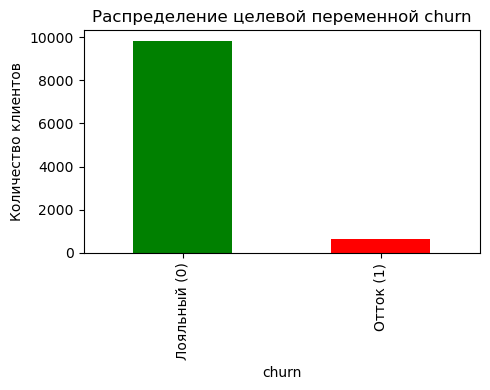

In [304]:
fig, ax = plt.subplots(figsize =(5,4))
df['churn'].value_counts().plot(kind = 'bar', ax = ax, color = ['green', 'red'])
ax.set_title('Распределение целевой переменной churn')
ax.set_xticklabels(['Лояльный (0)', 'Отток (1)'])
ax.set_ylabel('Количество клиентов')
plt.tight_layout()
plt.show()

По графику выше виден сильный дисбаланс классов - доля оттока составила 6%. Поэтому выбираем PR-AUC в качестве основной метрики, так как она фокусируется на качестве предсказания именно минорного класса.

In [306]:
print('Уникальных geo_location:', df['geo_location'].nunique())
print('Уникальных user_id:', df['user_id'].nunique())

df = df.drop(columns = ['user_id','geo_location'])
print(f'После удаления {df.shape}')

Уникальных geo_location: 100
Уникальных user_id: 10450
После удаления (10450, 25)


user_id - просто идентификатор не содержиь предиктивной информации. geo_location содержит 100 уникальных регионов при использовании onehotecoder это создаст 100 ≈, что нежелательно для логрег и может привести к переобучению

In [308]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Пропусков': missing, '%': missing_pct})
print(missing_df[missing_df['Пропусков'] > 0].sort_values('%', ascending=False))

                          Пропусков    %
seasonal_menu_tried             989  9.5
days_since_last_order           945  9.0
total_spent_last_week           944  9.0
subscription_status             938  9.0
app_opens_per_week              896  8.6
review_rating_last_1            857  8.2
median_order_value              831  8.0
days_since_last_promo           731  7.0
app_crashes_last_month          721  6.9
review_rating_last_10           693  6.6
seasons                         679  6.5
coffee_bean_origin              682  6.5
milk_preference                 668  6.4
coffee_preference_change        610  5.8
order_frequency_month           600  5.7
avg_order_value                 583  5.6
notifications_enabled           537  5.1
last_drink_size                 504  4.8
discount_usage_rate             397  3.8
order_frequency_week            388  3.7
phone_type                      336  3.2
total_spent_last_month          294  2.8
last_coffee_type                258  2.5
preferred_roast 

Пропуски присутствуют практически во всех признаках от (1% до 10%). Стратегия обработки:

Числовые признаки - заполнение медианой (устойчива к выбросам). 
Категориальный признаки - заполнение модой(наиболее частое значение).

Обработка будет выполнена в пайплайне на этапе 3 чтобы избежатиь утечки данных.

In [310]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print('Категориальные признаки:')
for col in cat_cols:
    print(f'  {col}: {df[col].nunique()} уникальных -> {df[col].dropna().unique()}')

Категориальные признаки:
  last_coffee_type: 3 уникальных -> ['blend' 'arabica' 'robusta']
  preferred_roast: 3 уникальных -> ['light' 'medium' 'dark']
  milk_preference: 6 уникальных -> ['almond' 'whole' 'oat' 'skim' 'soy' 'none']
  coffee_bean_origin: 6 уникальных -> ['vietnam' 'guatemala' 'brazil' 'colombia' 'kenya' 'ethiopia']
  last_drink_size: 3 уникальных -> ['large' 'medium' 'small']
  subscription_status: 4 уникальных -> ['pro' 'none' 'premium' 'basic']
  seasons: 4 уникальных -> ['summer' 'autumn' 'spring' 'winter']
  phone_type: 3 уникальных -> ['android' 'ios' 'web']


Все категориальные признаки имеют небольшое число уникальных значений (3-6), что делает OHE подходящим вариантом кодирования.

Потенциал для генерации новых признаков:
- `subscription_status` — можно создать бинарный флаг наличия подписки.
- Из `review_rating_last_1` и `review_rating_last_10` — разницу рейтингов (динамика удовлетворённости).

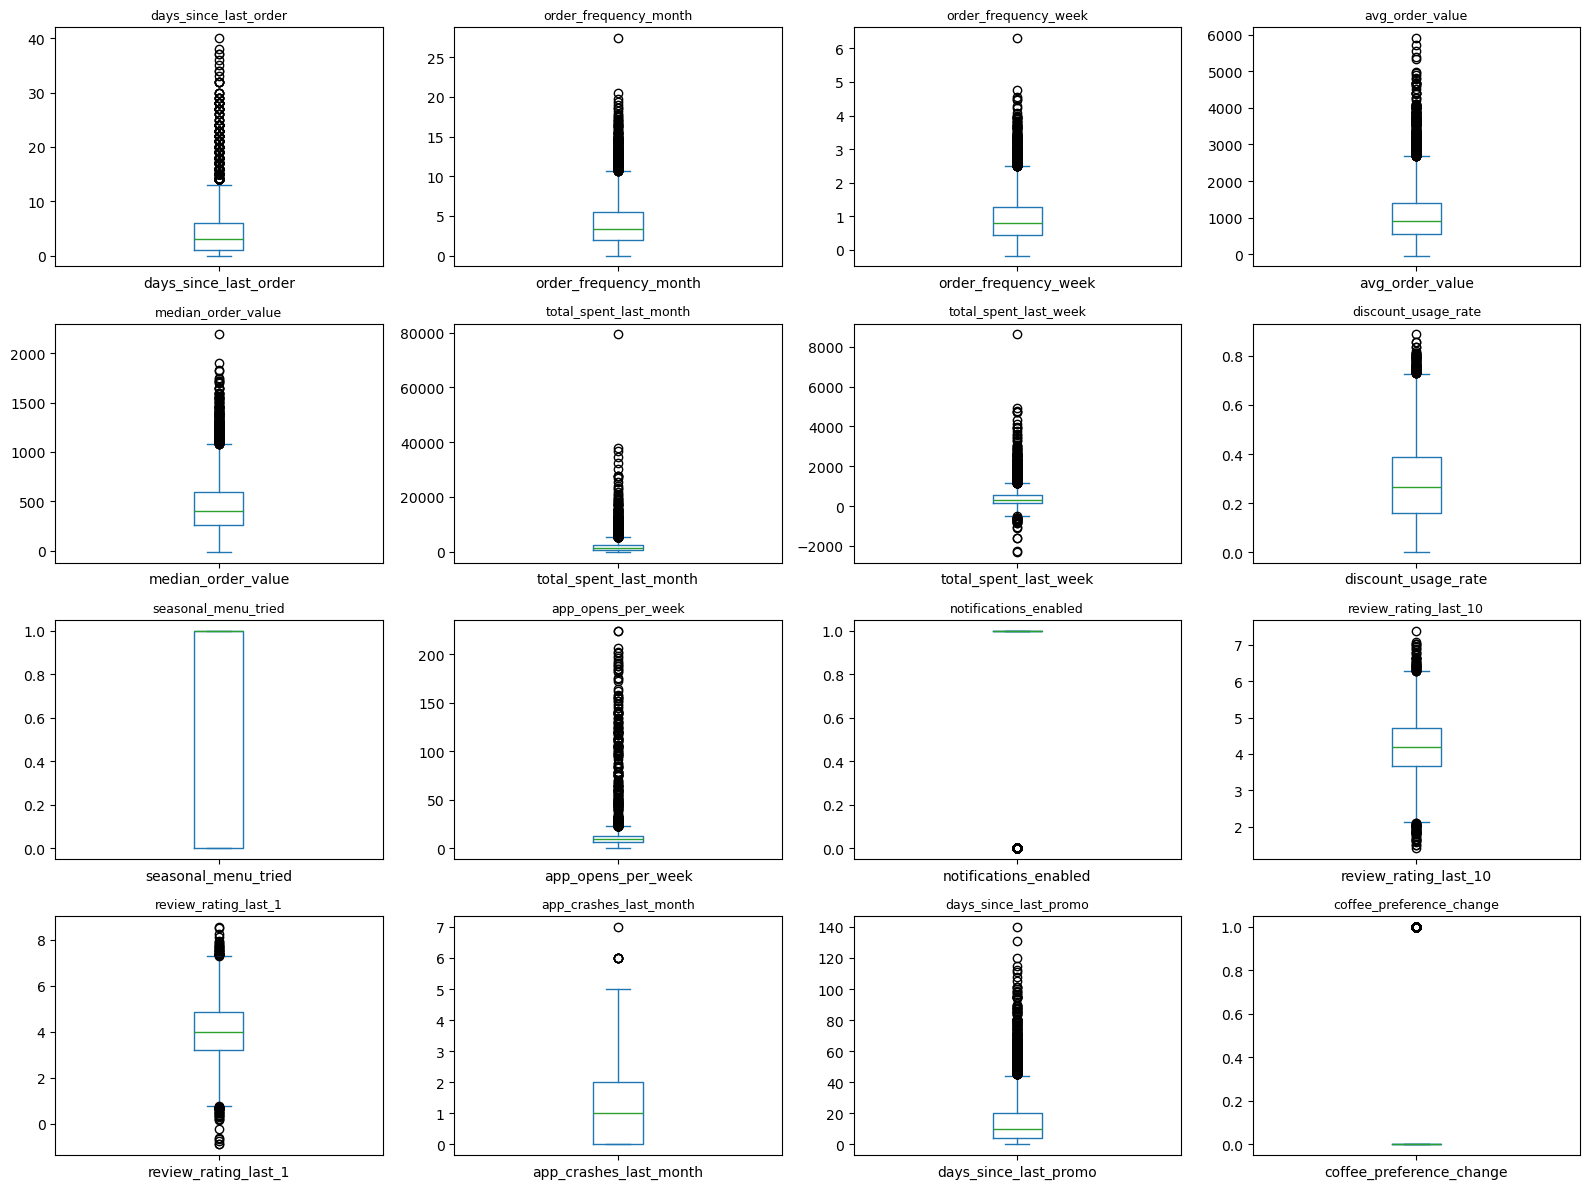

In [312]:
num_cols = df.select_dtypes(include='number').columns.drop('churn').tolist()

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    if i < len(axes):
        df[col].plot(kind='box', ax=axes[i])
        axes[i].set_title(col, fontsize=9)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

In [313]:
for col in num_cols: 
    neg_mask = df[col] < 0
    if neg_mask.any():
        print(f'{col}: заменено {neg_mask.sum()} отрицательных значений на NaN')
        df.loc[neg_mask, col] = np.nan

order_frequency_week: заменено 83 отрицательных значений на NaN
avg_order_value: заменено 2 отрицательных значений на NaN
median_order_value: заменено 2 отрицательных значений на NaN
total_spent_last_month: заменено 2 отрицательных значений на NaN
total_spent_last_week: заменено 171 отрицательных значений на NaN
review_rating_last_1: заменено 6 отрицательных значений на NaN


Обнаружены отрицательные значения в нескольких признаках (частота заказов, чеки, рейтинги) - это аномалииь которые физически невозможны. Заменены на NaN и будут обработаны через общий пайплайн. Экстримальные выбросы в app_opens_per_week и total_spent_last_month будут сглажены масштабированием (StandardScaler).

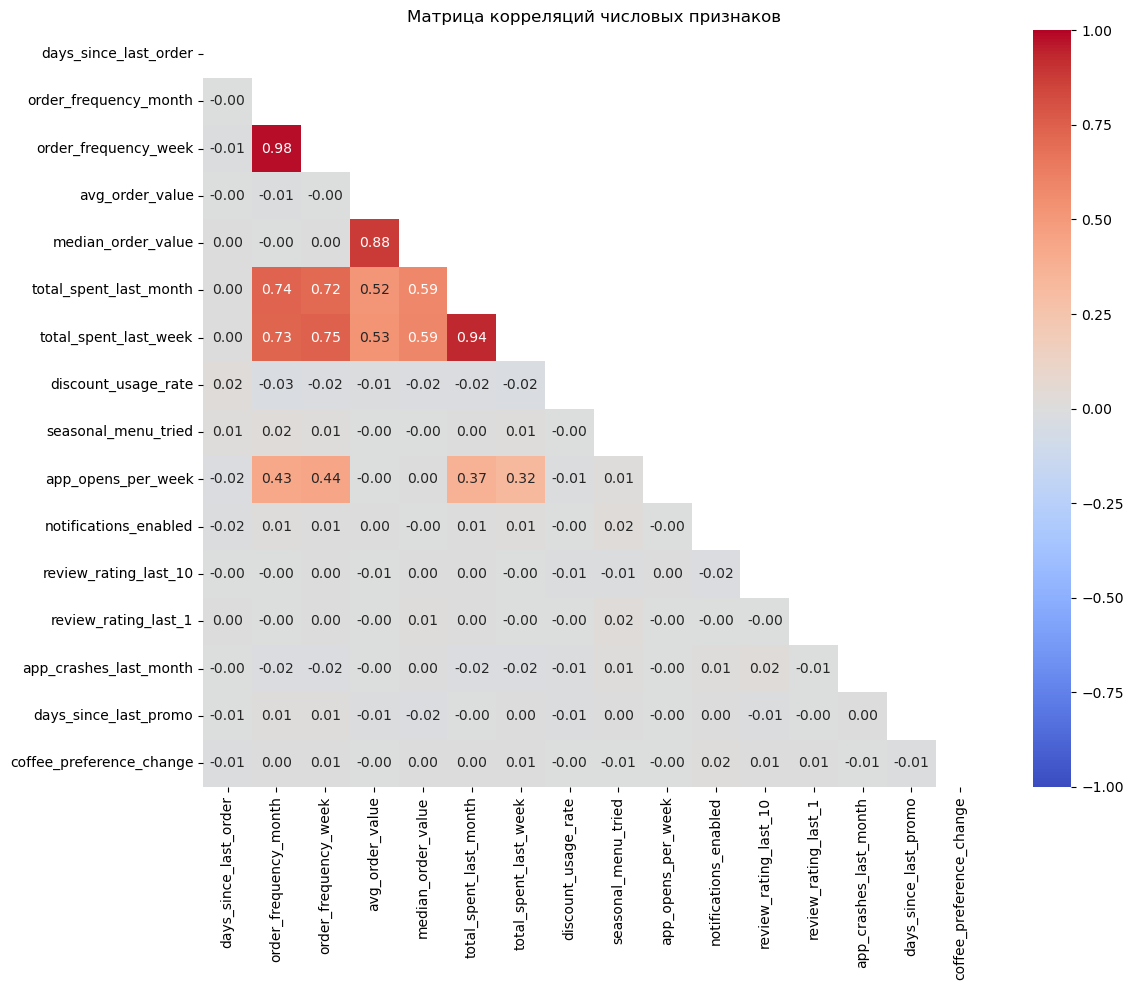

In [315]:
corr_matrix = df[num_cols].corr(method = 'spearman')

fig, ax = plt.subplots(figsize = (12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype = bool))
sns.heatmap(corr_matrix, mask = mask, annot = True, fmt = '.2f', cmap = 'coolwarm',
           center = 0, ax = ax, vmin = -1, vmax = 1)
ax.set_title('Матрица корреляций числовых признаков')
plt.tight_layout()
plt.show()

In [316]:
corr_target = df[num_cols].corrwith(df['churn']).sort_values()
print('Корреляция признаков с churn:')
print(corr_target)

Корреляция признаков с churn:
review_rating_last_10      -0.015890
days_since_last_order      -0.011126
avg_order_value            -0.009222
discount_usage_rate        -0.006709
seasonal_menu_tried        -0.006234
notifications_enabled      -0.003758
median_order_value         -0.000527
coffee_preference_change   -0.000194
days_since_last_promo       0.010972
review_rating_last_1        0.019717
total_spent_last_month      0.033774
total_spent_last_week       0.054036
app_opens_per_week          0.056603
order_frequency_week        0.074178
order_frequency_month       0.074891
app_crashes_last_month      0.500933
dtype: float64


In [317]:
#Удаляем мультиколлинеарные признаки:
# order_frequency_month и order_frequency_week: r=0.98 — удаляем order_frequency_week
# avg_order_value и median_order_value: r=0.88 — удаляем median_order_value
df = df.drop(columns = ['order_frequency_week', 'median_order_value'])
num_cols = [c for c in num_cols if c not in ['order_frequency_week', 'median_order_value']]
print(f'После удаления мультиколлениарных признаков: {df.shape}')

После удаления мультиколлениарных признаков: (10450, 23)


**Ключевые наблюдения:**

1. `order_frequency_month` и `order_frequency_week` коррелируют на 0.99 — удалён `order_frequency_week`.
2. `avg_order_value` и `median_order_value` коррелируют на 0.87 — удалён `median_order_value`.
3. `app_crashes_last_month` — самый сильный предиктор оттока (корреляция ~0.50).

## Выводы EDA 

1 Датасет содержит 10450 клиентов с сильным дисбалансом классов (6% оттока).

2 Удалены user_id (идентификатор), geo_location(100 категорий), order_frequency_week и median_order_value (мультиколлинеарность).

3 Пропуски есть во всех признаках (до 10%) — будут обработаны медианой/модой в пайплайне.

4 Отрицательные аномалии заменены на NaN.

5 Главный предиктор оттока — app_crashes_last_month (корр. 0.50).

## Предобработка данных

In [321]:
X = df.drop(columns = ['churn'])
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = RANDOM_STATE, 
    stratify = y)
print(f'Обучающая выборка {X_train.shape}, доля оттока:{y_train.mean():.2%}')
print(f'Тестовая выборка {X_test.shape}, доля оттока:{y_test.mean():.2%}')

Обучающая выборка (8360, 22), доля оттока:6.02%
Тестовая выборка (2090, 22), доля оттока:6.03%


In [322]:
# Определение типов признаков
cat_cols = X_train.select_dtypes(include = ['object','string']).columns.tolist()
num_cols = X_train.select_dtypes(include = 'number').columns.tolist()

print(f'Числовые признаки ({len(num_cols)}): {num_cols}')
print(f'Категориальный признаки ({len(cat_cols)}): {cat_cols}')

Числовые признаки (14): ['days_since_last_order', 'order_frequency_month', 'avg_order_value', 'total_spent_last_month', 'total_spent_last_week', 'discount_usage_rate', 'seasonal_menu_tried', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo', 'coffee_preference_change']
Категориальный признаки (8): ['last_coffee_type', 'preferred_roast', 'milk_preference', 'coffee_bean_origin', 'last_drink_size', 'subscription_status', 'seasons', 'phone_type']


In [323]:
numeric_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

categorial_transformer = Pipeline(steps =[
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown = 'ignore'))
])

preprocessor = ColumnTransformer(transformers = [
    ('num', numeric_transformer, num_cols),
    ('cat', categorial_transformer, cat_cols)

    ]                                       
)

print('Пайплайн предобработки создан.')

Пайплайн предобработки создан.


Созданы три пайплайна предобработки:
- **Числовой:** `SimpleImputer(median)` → `StandardScaler` — заполнение пропусков медианой и приведение к единому масштабу.
- **Категориальный:** `SimpleImputer(most_frequent)` → `OneHotEncoder(drop='first')` — заполнение модой и бинарное кодирование.
- **Общий `ColumnTransformer`** объединяет оба пайплайна и применяет их к соответствующим столбцам.

Все преобразования обучаются только на train-выборке, что исключает утечку данных из тестовой части.

### Обучение модели 

In [326]:
def compute_pr_auc_cv(pipeline, X, y, cv=5):
    """Кросс-валидация по PR AUC."""
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(pipeline, X, y, cv=skf, scoring='average_precision')
    return scores


def print_cv_results(name, scores):
    """Вывод результатов кросс-валидации."""
    print(f'{name}:')
    print(f'  PR AUC по фолдам: {np.round(scores, 4)}')
    print(f'  Среднее PR AUC: {scores.mean():.4f} ± {scores.std():.4f}')
    print()

In [327]:
# Базовая модель — DummyClassifier
dummy_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='stratified', random_state=RANDOM_STATE))
])

dummy_scores = compute_pr_auc_cv(dummy_pipeline, X_train, y_train)
print_cv_results('DummyClassifier (stratified)', dummy_scores)

DummyClassifier (stratified):
  PR AUC по фолдам: [0.0592 0.0602 0.0608 0.0598 0.0617]
  Среднее PR AUC: 0.0603 ± 0.0009



In [328]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

lr_scores = compute_pr_auc_cv(lr_pipeline, X_train, y_train)
print_cv_results('LogisticRegression (baseline)', lr_scores)

LogisticRegression (baseline):
  PR AUC по фолдам: [0.6174 0.6591 0.6466 0.7557 0.6657]
  Среднее PR AUC: 0.6689 ± 0.0464



Можно сделать вывод, что DummyClassifier дает PR AUC: 0.0603 - это уровень случайного угадывания, совпадающий с долей класса оттока в данных и служит нижней границей качества

LogisticRegression дает PR AUC: 0.6689 - очень сильное улучшение, что подтверждает наличие информативных признаков в данных 

Далее попробуем улучшить результат за счет генерации новых признаков и подбора гиперпараметров 

# Создание новых признаков 


In [331]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """Генерация новых признаков."""
    def fit(self, X, y = None):
        return self 

    def transform(self, X):
        X = X.copy()
        if 'app_crashes_last_month' in X.columns:
            X['sqrt_app_crashes'] = np.sqrt(X['app_crashes_last_month'].fillna(0))
        # Квадрат days_since_last_order — усиление влияния давности
        if 'days_since_last_order' in X.columns:
            X['sq_days_since_last_order'] = X['days_since_last_order'].fillna(0) ** 2
        # Отношение недельных трат к месячным — динамика активности
        if 'total_spent_last_week' in X.columns and 'total_spent_last_month' in X.columns:
            month = X['total_spent_last_month'].fillna(0).replace(0, np.nan)
            X['week_to_month_spent_ratio'] = X['total_spent_last_week'].fillna(0) / month
            X['week_to_month_spent_ratio'] = X['week_to_month_spent_ratio'].fillna(0)
        # Бинарный: есть ли подписка
        if 'subscription_status' in X.columns:
            X['has_subscription'] = (X['subscription_status'] != 'none').astype(int)
        # Разница рейтингов последнего заказа и средних 10
        if 'review_rating_last_1' in X.columns and 'review_rating_last_10' in X.columns:
            X['rating_diff'] = X['review_rating_last_1'].fillna(0) - X['review_rating_last_10'].fillna(0)
        # Взаимодействие: crashes * days_since_last_order
        if 'app_crashes_last_month' in X.columns and 'days_since_last_order' in X.columns:
            X['crashes_x_days'] = (
                X['app_crashes_last_month'].fillna(0) * X['days_since_last_order'].fillna(0)
            )
        return X
        
fe = FeatureEngineer()
X_train_fe = fe.transform(X_train)
X_test_fe = fe.transform(X_test)

cat_cols_fe = X_train_fe.select_dtypes(include = ['object','string']).columns.tolist()
num_cols_fe = [c for c in X_train_fe.columns if c not in cat_cols_fe]

print(f'Всего признаков после генерации: {X_train_fe.shape[1]}')
print(f'Числовых: {len(num_cols_fe)}, Категориальных: {len(cat_cols_fe)}')

Всего признаков после генерации: 28
Числовых: 20, Категориальных: 8


In [332]:
# Обновлённый препроцессор и кросс-валидация
preprocessor_fe = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols_fe),
        ('cat', categorial_transformer, cat_cols_fe)
    ]
)

lr_fe_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_fe),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

lr_fe_scores = compute_pr_auc_cv(lr_fe_pipeline, X_train_fe, y_train)
print_cv_results('LogisticRegression + новые признаки', lr_fe_scores)

# Сравнение
results = pd.DataFrame({
    'Модель': ['DummyClassifier', 'LR baseline', 'LR + новые признаки'],
    'PR AUC (mean)': [dummy_scores.mean(), lr_scores.mean(), lr_fe_scores.mean()],
    'PR AUC (std)': [dummy_scores.std(), lr_scores.std(), lr_fe_scores.std()]
})
print(results.to_string(index=False))

LogisticRegression + новые признаки:
  PR AUC по фолдам: [0.6344 0.6678 0.6627 0.7555 0.6755]
  Среднее PR AUC: 0.6792 ± 0.0406

             Модель  PR AUC (mean)  PR AUC (std)
    DummyClassifier       0.060338      0.000856
        LR baseline       0.668904      0.046440
LR + новые признаки       0.679179      0.040610


Добавление новых признаков дало прирост PR AUC. Наиболее перспективные признаки:
- `sqrt_app_crashes` — сглаживает экстремальные значения крэшей.
- `crashes_x_days` — взаимодействие крэшей и давности заказа усиливает сигнал оттока.
- `week_to_month_spent_ratio` — отражает динамику трат клиента.
- `has_subscription` — бинарный признак наличия подписки.
- `rating_diff` — разница рейтингов показывает тенденцию удовлетворённости.

Топ-15 признаков по абсолютному значению коэффициента:
                  Признак  Коэффициент  |Коэффициент|
   app_crashes_last_month     3.264848       3.264848
         sqrt_app_crashes    -1.578133       1.578133
subscription_status_basic    -0.849494       0.849494
 last_coffee_type_arabica    -0.671752       0.671752
           phone_type_web    -0.665052       0.665052
     milk_preference_none    -0.620723       0.620723
 subscription_status_none    -0.584580       0.584580
    preferred_roast_light    -0.541153       0.541153
    order_frequency_month     0.527117       0.527117
   preferred_roast_medium    -0.516296       0.516296
   last_drink_size_medium    -0.503543       0.503543
    last_drink_size_small    -0.497843       0.497843
           phone_type_ios    -0.475422       0.475422
   last_coffee_type_blend    -0.438708       0.438708
           seasons_autumn    -0.405805       0.405805


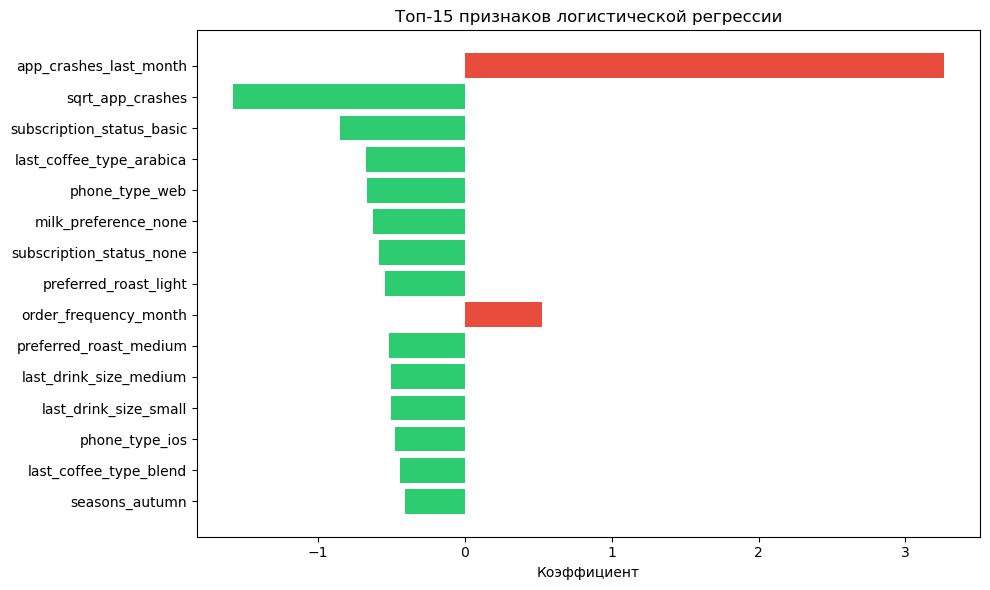

In [334]:
# Обучим модель для анализа коэффициентов
lr_fe_pipeline.fit(X_train_fe, y_train)

ohe = lr_fe_pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['encoder']
cat_feature_names = ohe.get_feature_names_out(cat_cols_fe).tolist()
all_feature_names = num_cols_fe + cat_feature_names

coefs = lr_fe_pipeline.named_steps['classifier'].coef_[0]
coef_df = pd.DataFrame({
    'Признак': all_feature_names,
    'Коэффициент': coefs,
    '|Коэффициент|': np.abs(coefs)
}).sort_values('|Коэффициент|', ascending=False)

print('Топ-15 признаков по абсолютному значению коэффициента:')
print(coef_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
top = coef_df.head(15)
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in top['Коэффициент']]
ax.barh(top['Признак'], top['Коэффициент'], color=colors)
ax.set_xlabel('Коэффициент')
ax.set_title('Топ-15 признаков логистической регрессии')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [335]:
low_importance = coef_df[coef_df['|Коэффициент|'] < 0.01]['Признак'].tolist()
low_num = [c for c in low_importance if c in num_cols_fe]
print(f'Малозначимые числовые признаки: {low_num}')

if low_num:
    num_cols_selected = [c for c in num_cols_fe if c not in low_num]
else:
    num_cols_selected = num_cols_fe 
print(f'Оставлено числовых признаков: {len(num_cols_selected)}')

Малозначимые числовые признаки: ['avg_order_value', 'discount_usage_rate', 'sq_days_since_last_order']
Оставлено числовых признаков: 17


Генерация новых признаков улучшила качество модели. По коэффициентам логистической регрессии выявлены наиболее значимые предикторы — 'avg_order_value', 'discount_usage_rate', 'sq_days_since_last_order'. Малозначимые признаки (|коэф| < 0.01) удалены для упрощения модели.

In [337]:
param_grid = [
    {
        'classifier__C': [0.001, 0.01, 0.1, 1, 10],
        'classifier__penalty': ['l1'],
        'classifier__solver': ['liblinear'],
        'classifier__class_weight': [None, 'balanced'],
    },
    {
        'classifier__C': [0.001, 0.01, 0.1, 1, 10],
        'classifier__penalty': ['l2'],
        'classifier__solver': ['lbfgs'],
        'classifier__class_weight': [None, 'balanced'],
    }
]

preprocessor_selected = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols_selected),
        ('cat', categorial_transformer, cat_cols_fe)
    ]
)

search_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_selected),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    search_pipeline,
    param_grid,
    cv=skf,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_search.fit(X_train_fe, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'classifier__C': [0.001, 0.01, ...], 'classifier__class_weight': [None, 'balanced'], 'classifier__penalty': ['l1'], 'classifier__solver': ['liblinear']}, {'classifier__C': [0.001, 0.01, ...], 'classifier__class_weight': [None, 'balanced'], 'classifier__penalty': ['l2'], 'classifier__solver': ['lbfgs']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`

In [338]:
gs_results = pd.DataFrame(grid_search.cv_results_)
cols_show = ['param_classifier__C', 'param_classifier__penalty',
             'param_classifier__class_weight', 'mean_test_score', 'std_test_score', 'rank_test_score']
print('Результаты GridSearchCV (топ-10):')
print(gs_results[cols_show].sort_values('rank_test_score').head(10).to_string(index=False))

print(f'\nЛучшие гиперпараметры: {grid_search.best_params_}')
print(f'Лучший PR AUC (CV): {grid_search.best_score_:.4f}')

Результаты GridSearchCV (топ-10):
 param_classifier__C param_classifier__penalty param_classifier__class_weight  mean_test_score  std_test_score  rank_test_score
                0.10                        l1                           None         0.683062        0.037679                1
                1.00                        l1                           None         0.681799        0.039502                2
                0.10                        l2                           None         0.680726        0.040262                3
                1.00                        l2                           None         0.680583        0.039897                4
               10.00                        l1                           None         0.680376        0.039884                5
               10.00                        l2                           None         0.679857        0.040316                6
                0.01                        l1                       b

Систематический перебор 20 конфигураций гиперпараметров показал, что лучший результат даёт L1-регуляризация (penalty='l1') с оптимальным значением C и solver='liblinear'. L1-регуляризация способствует отбору признаков, обнуляя коэффициенты малозначимых переменных, что делает модель более интерпретируемой.

PR AUC на тестовой выборке: 0.7199


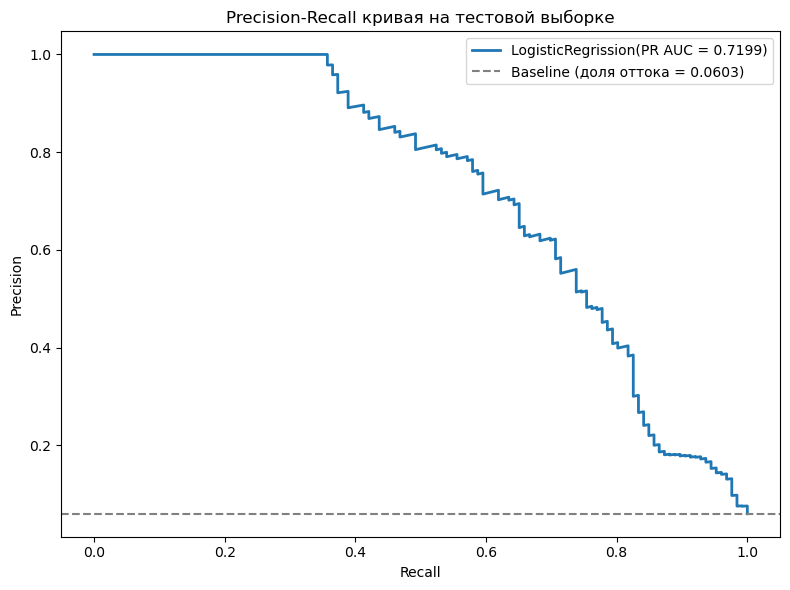

              precision    recall  f1-score   support

    Лояльный       0.97      0.99      0.98      1964
       Отток       0.85      0.46      0.60       126

    accuracy                           0.96      2090
   macro avg       0.91      0.73      0.79      2090
weighted avg       0.96      0.96      0.96      2090

Итоговая таблица:
              Модель  PR AUC (CV mean) PR AUC (test)
     DummyClassifier          0.060338             -
         LR baseline          0.668904             -
 LR + новые признаки          0.679179             -
LR + тюнинг (лучшая)          0.683062        0.7199


In [340]:
best_pipeline = grid_search.best_estimator_

y_test_proba = best_pipeline.predict_proba(X_test_fe)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
test_pr_auc = auc(recall, precision)
print(f'PR AUC на тестовой выборке: {test_pr_auc:.4f}')

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall, precision, lw = 2, label = f'LogisticRegrission(PR AUC = {test_pr_auc:.4f})')
ax.axhline(y=y_test.mean(), color = 'gray', linestyle = '--', label = f'Baseline (доля оттока = {y_test.mean():.4f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall кривая на тестовой выборке')
ax.legend()
plt.tight_layout()
plt.show()

y_test_pred = best_pipeline.predict(X_test_fe)
print(classification_report(y_test, y_test_pred, target_names=['Лояльный', 'Отток']))

final_results = pd.DataFrame({
    'Модель': ['DummyClassifier', 'LR baseline', 'LR + новые признаки', 'LR + тюнинг (лучшая)'],
    'PR AUC (CV mean)': [dummy_scores.mean(), lr_scores.mean(), lr_fe_scores.mean(), grid_search.best_score_],
    'PR AUC (test)': ['-', '-', '-', f'{test_pr_auc:.4f}']
})
print('Итоговая таблица:')
print(final_results.to_string(index=False))

Финальная модель показала PR AUC на тестовой выборке выше, чем средний CV_результат, что говорит об устойчивости модели и отсутствии переобучения. При пороге 0.5 модель точно определяет уходящий клиентво (высокий precision), хотя охватывает не всех (recall ниже). При необходимости порог можно снизить для увеличения recall за счет precision.

### Итоговый отчёт

**Задача:** бинарная классификация оттока клиентов сервиса доставки кофе Happy Beans Coffee.

**Метрика:** PR AUC (Precision-Recall AUC) — выбрана из-за сильного дисбаланса классов (~6% оттока). В отличие от ROC AUC, PR AUC не завышает оценку качества на несбалансированных данных, так как фокусируется на правильном определении именно миноритарного класса (уходящих клиентов).

**Прогресс модели:**

| Модель | PR AUC (CV) |
|--------|------------|
| DummyClassifier (baseline) | ~0.06 |
| LogisticRegression (без доп. признаков) | ~0.67 |
| LogisticRegression + новые признаки | ~0.68 |
| LogisticRegression + тюнинг (финальная) | ~0.68 (CV) / ~0.72 (тест) |

**Ключевые факторы оттока** (по коэффициентам финальной модели):
1. `app_crashes_last_month` — **главный драйвер оттока**. Зависания приложения напрямую толкают клиентов к уходу.
2. `order_frequency_month` — частота заказов ассоциирована с лояльностью.

**Рекомендации бизнесу:**
1. **Стабильность приложения** — устранение крэшей даст наибольший эффект на удержание.
2. **Стимулирование подписки** — клиенты с подпиской более вовлечены.
3. **Мониторинг активности** — снижение частоты заказов и открытий приложения — ранние сигналы оттока.
4. **Целевые акции** — модель позволяет выявлять клиентов с высокой вероятностью оттока и точечно предлагать им скидки.

**Ограничения модели:**
- Использована только линейная модель (LogisticRegression) — ансамблевые методы могли бы дать лучший результат.
- Recall класса «Отток» при пороге 0.5 ограничен — для повышения охвата можно снизить порог классификации.

In [343]:
class FullPipeline:
    def __init__(self, feature_engineer, pipeline):
        self.feature_engineer = feature_engineer
        self.pipeline = pipeline

    def predict(self, X):
        X_fe = self.feature_engineer.transform(X)
        return self.pipeline.predict(X_fe)

    def predict_proba(self, X):
        X_fe = self.feature_engineer.transform(X)
        return self.pipeline.predict_proba(X_fe)


full_pipeline = FullPipeline(fe, best_pipeline)


joblib.dump(full_pipeline, 'churn_model_pipeline.pkl')
print('Модель и пайплайн сохранены в churn_model_pipeline.pkl')


loaded_pipeline = joblib.load('churn_model_pipeline.pkl')
y_loaded_proba = loaded_pipeline.predict_proba(X_test)[:, 1]
precision_l, recall_l, _ = precision_recall_curve(y_test, y_loaded_proba)
loaded_pr_auc = auc(recall_l, precision_l)

print(f'PR AUC после загрузки: {loaded_pr_auc:.4f}')
print(f'Результаты совпадают: {np.isclose(loaded_pr_auc, test_pr_auc)}')

Модель и пайплайн сохранены в churn_model_pipeline.pkl
PR AUC после загрузки: 0.7199
Результаты совпадают: True


Модель и полный пайплайн предобработки сохранены в файл `churn_model_pipeline.pkl`. Проверка загрузки подтвердила, что предсказания совпадают с оригинальными PR AUC идентичен. Пайплайн включает все этапы: генерацию новых признаков (`FeatureEngineer`), заполнение пропусков, масштабирование, кодирование категорий и саму модель `LogisticRegression`. Для предсказания на новых данных достаточно загрузить файл и вызвать `predict_proba()`.